## 💥 Apa Itu Multicollinearity?

Multicollinearity terjadi ketika dua atau lebih fitur (variabel independen) dalam dataset **memiliki korelasi tinggi satu sama lain**.

Artinya: satu fitur bisa diprediksi dari fitur lain → membuat model bingung saat menilai kontribusi masing-masing fitur.

### ❗Mengapa Multicollinearity Itu Masalah?

❌ Model Linear Menjadi Tidak Stabil
<br>Koefisien regresi bisa menjadi sangat besar atau berubah tanda
<br>Prediksi bisa tetap akurat, tapi interpretasi fitur jadi kacau

❌ Inferensi Tidak Valid
- P-value menjadi tidak akurat
- Sulit menjelaskan variabel mana yang paling memengaruhi target

❌ Overfitting Potensial
<br>Model bisa "terlalu cocok" pada data latih dan gagal generalisasi

## ✅ Bagaimana Cara Mendeteksi Multicollinearity?

### 1. 📊 Correlation Matrix

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Contoh dataframe
df = pd.DataFrame({
    'X1': [1, 2, 3, 4, 5],
    'X2': [2, 4, 6, 8, 10],
    'X3': [5, 3, 6, 2, 4]
})

In [4]:
# Korelasi
corr_matrix = df.corr()

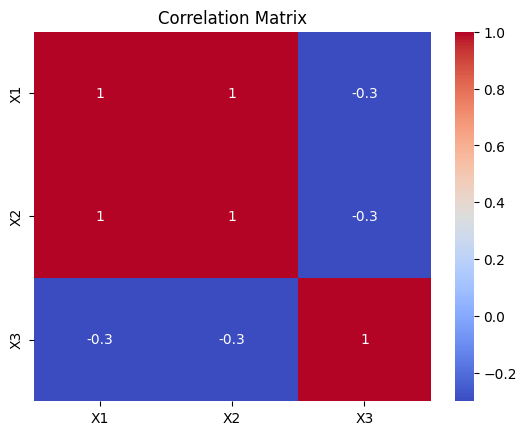

In [5]:
# Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Note:**
Jika ada korelasi > 0.8 atau < -0.8 antara fitur, itu tanda awal multicollinearity.

### 2. 📐 VIF (Variance Inflation Factor)

**Mengukur seberapa besar sebuah fitur bisa dijelaskan oleh fitur lain.**

VIF tinggi → fitur tersebut sangat berkorelasi dengan fitur lain  
Interpretasi VIF:
> 1–5: aman  
> 5: mulai mengkhawatirkan  
> 10: indikasi kuat multicollinearity

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [7]:
# Dataset contoh
df = pd.DataFrame({
    'X1': [1, 2, 3, 4, 5],
    'X2': [2, 4, 6, 8, 10],  # Sangat berkorelasi dengan X1
    'X3': [5, 3, 6, 2, 4]
})

In [8]:
X = add_constant(df)  # Tambah konstanta untuk intercept

In [9]:
# Hitung VIF
vif_df = pd.DataFrame()
vif_df["feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

C:\Users\ryana\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [10]:
print(vif_df)

  feature        VIF
0   const  18.692308
1      X1        inf
2      X2        inf
3      X3   1.098901


#### 🔄Contoh Drop Fitur dengan VIF

In [11]:
# Misalnya kita tahu X2 dan X1 sangat mirip
df_reduced = df.drop(columns=['X2'])

In [12]:
# Ulangi hitung VIF pada df_reduced
X_reduced = add_constant(df_reduced)
vif_df = pd.DataFrame()
vif_df["feature"] = X_reduced.columns
vif_df["VIF"] = [variance_inflation_factor(X_reduced.values, i) for i in range(X_reduced.shape[1])]
print(vif_df)

  feature        VIF
0   const  18.692308
1      X1   1.098901
2      X3   1.098901


#### 🛠️ Cara Mengatasi Multicollinearity

| Teknik                                | Penjelasan                                                              |
| ------------------------------------- | ----------------------------------------------------------------------- |
| ❌ Hapus salah satu fitur              | Drop fitur yang redundant (serupa dengan fitur lain)                    |
| 📉 PCA (Principal Component Analysis) | Reduksi dimensi ke fitur-fitur baru yang orthogonal (tidak berkorelasi) |
| ⚖️ Regularisasi (Ridge, Lasso)        | Penalti terhadap koefisien besar — mengurangi dampak multicollinearity  |
| 🧠 Domain knowledge                   | Pilih fitur yang paling logis berdasarkan konteks / bisnis              |

#### ✅ Kesimpulan:

> Multicollinearity tidak selalu mengganggu akurasi prediksi, tapi bisa merusak interpretasi.  
> Gunakan correlation matrix dan VIF untuk mendeteksi.  
> Tangani dengan drop fitur, PCA, atau regularisasi sesuai tujuan modeling.